In [ ]:
#Quest 1+2

#Question 1
#https://www.youtube.com/@gerstnerlab

'''
# Code for homogeneous and inhomogeneous Poisson processes
# Calculate Fano factor, ISI Coefficient of Variation
# Plot ISI CV and Fano factor over refractory periods
'''

import numpy as np
import matplotlib.pyplot as plt
import math

#parameters
isi = []  #array to store isi
fire_rate = 35  #fire rate (Hz) - const for homogeneous
total_time = 0.5  #total simulation time (s)
time_bins = [0.010, 0.050, 0.100]  #time bin lengths (s)
nBins = int(total_time / min(time_bins))  #n of bins
dur_refract = 0.005  #refractory period (s)
avg_isi = 1 / fire_rate #average time between spikes



In [ ]:

def generate_spike_train(total_time, fire_rate, dur_refract):
    current_time = 0
    spike_times = []
    spike_train = np.zeros(int(total_time * fire_rate))  #to be spike train
    
    while current_time < total_time:
        #generate next spike time using poisson process:
        spike_interval = np.random.exponential(1 / fire_rate)  #isi
        current_time += spike_interval
        
        if current_time >= total_time:
            break  #stop if spike time > total_time
        
        #mark spike
        spike_times.append(current_time)
        #ensure the index within bounds

        index = int(current_time * fire_rate)
        if index < len(spike_train):  #check if index valid
            spike_train[index] = 1  #mrk spike
        #apply refractory period
        current_time += dur_refract
    
    #calculate isi
    isi_durations = np.diff(spike_times) if len(spike_times) > 1 else []
    
    return spike_times, spike_train, isi_durations


[0.01456642660318695, 0.06700528249970202, 0.06760342384167332, 0.08190324565679827, 0.08290463694203036, 0.09446994012421804, 0.10520106376950149, 0.11823583706609093, 0.12276959473865391, 0.192912876308789, 0.23369558106411248, 0.24515258196200077, 0.2765665273573986, 0.2888354299685609, 0.29094823488366295, 0.33261807976767543, 0.33759406105648987, 0.3396370825210624, 0.3510162499978898, 0.38313684460781994, 0.3903926375415901, 0.40378597912028, 0.40755421323020413, 0.42603265454922284, 0.46071593520648796, 0.47545613315160945, 0.48200368639648883, 0.5012715305263545, 0.55749567232186, 0.5652824255266197, 0.5760467811220676, 0.6183102524632219, 0.6233272248119971, 0.6950806684215208, 0.7213716263328588, 0.7231140472777354, 0.7625413748168359, 0.7986760995376504, 0.8046614207837883, 0.8357002897790249, 0.8370013695306328, 0.8631658125937431, 0.8940336147160739, 0.9090454244847738, 0.9450637944192313, 0.9532809506185559, 0.9717390027698867, 0.9725876538342807, 0.9931722739242509, 0.99

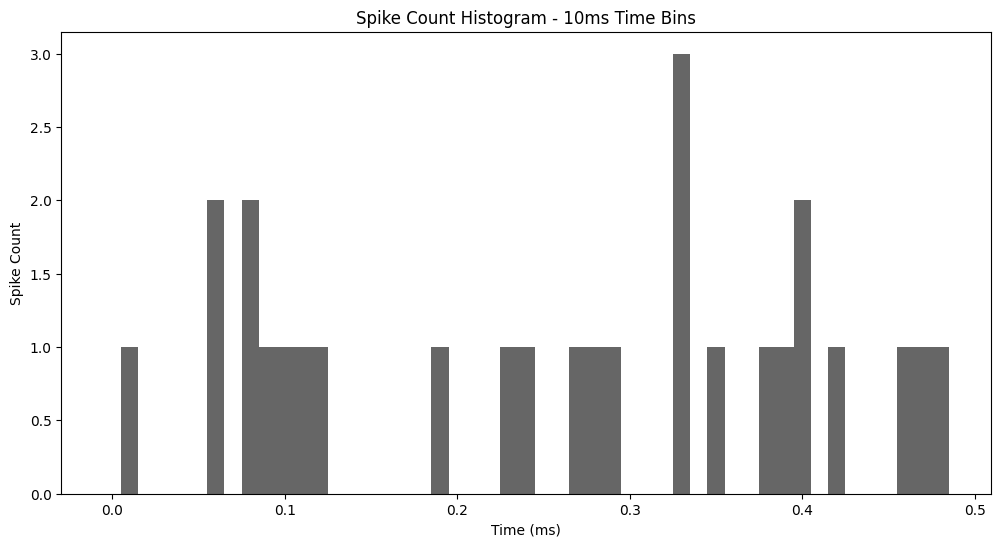

In [ ]:
spike_times, spike_train, isi_durations = generate_spike_train(fire_rate=35, dur_refract=0, total_time=500)

print(spike_times)
print(spike_train)

#choose a smaller time bin to see individual spikes
time_bin = 0.010  #10ms time bin for clearer visualization
time_bins = np.arange(0, total_time, time_bin)
spike_counts, _ = np.histogram(spike_times, bins=time_bins)
#plotting the histogram
plt.figure(figsize=(12, 6))
plt.bar(time_bins[:-1], spike_counts, width=time_bin, color='k', alpha=0.6, label='Spike Count')
plt.xlabel('Time (ms)')
plt.ylabel('Spike Count')
plt.title('Spike Count Histogram - 10ms Time Bins')
plt.show()

Fano (10ms): [np.float64(0.7610169491525424), np.float64(0.8295114656031903), np.float64(0.6610169491525424), np.float64(0.7288135593220343), np.float64(0.7627118644067795), np.float64(0.7796610169491527), np.float64(0.7457627118644067), np.float64(0.7457627118644067), np.float64(0.7627118644067795), np.float64(0.7118644067796609), np.float64(0.7118644067796609), np.float64(0.7627118644067795), np.float64(0.7457627118644067), np.float64(0.8474576271186439), np.float64(0.8305084745762709), np.float64(0.8474576271186439), np.float64(0.7118644067796609), np.float64(0.8644067796610169), np.float64(0.7796610169491527), np.float64(0.8135593220338987), np.float64(0.8135593220338986), np.float64(0.7966101694915255), np.float64(0.8474576271186439), np.float64(0.8305084745762709), np.float64(0.88135593220339), np.float64(0.864406779661017), np.float64(0.8135593220338986), np.float64(0.8135593220338986)]
Fano (50ms): [np.float64(1.1818181818181817), np.float64(0.3957219251336898), np.float64(0.38

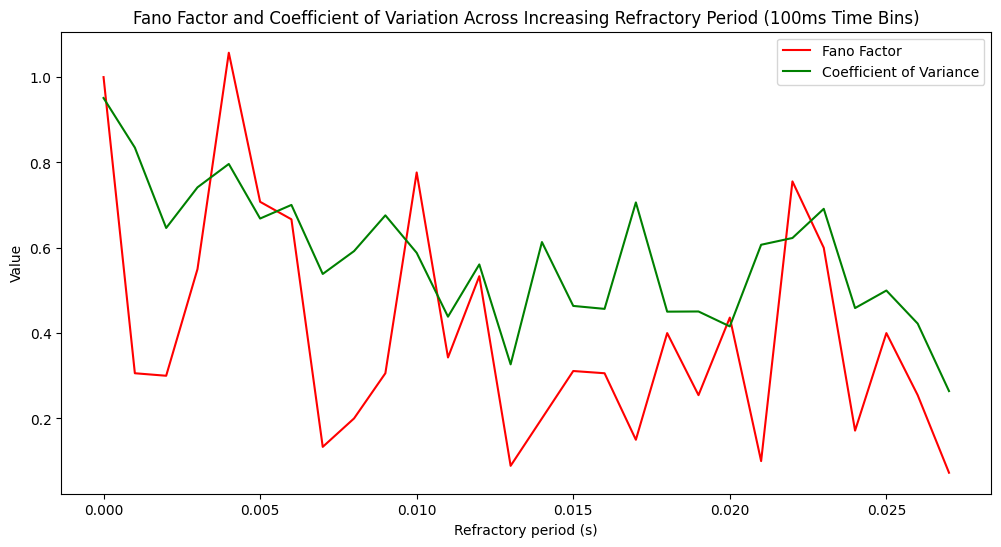

In [ ]:

#arrays to hold new Fano and CV values
fano_10 = []  #10ms bin
fano_50 = []  #50ms bin
fano_100 = []  #100ms bin

cvs_10 = []  #10ms bin
cvs_50 = []  #50ms bin
cvs_100 = []  #100ms bin

#time bins (10ms, 50ms, 100ms)
time_bins = [10 / 1000, 50 / 1000, 100 / 1000]  #convert ms to seconds

#refractory period range 0 : 0.028 seconds
range_refract = np.arange(0, 0.028, 0.001)

#loop over each refractory period
for refract in range_refract:
    #generate spike times and spike train for the current refractory period
    spike_times, spike_train, isi_durations = generate_spike_train(total_time, fire_rate, refract)

    #convert spike times into binary spike train for analysis
    time_step = 1 / (fire_rate * 10)  #define time resolution for spike train (10x finer than firing rate)
    bin_count = int(total_time / time_step)
    binary_spike_train = np.zeros(bin_count, dtype=int)

    #fill binary spike train based on spike times
    for spike_time in spike_times:
        index = int(spike_time / time_step)
        if index < bin_count:
            binary_spike_train[index] = 1

    #loop through each time bin and calculate Fano factor and CV
    for i, bin_size in enumerate(time_bins):
        bin_width = int(bin_size / time_step)  #convert bin size to number of steps in binary spike train
        spike_counts = [
            np.sum(binary_spike_train[start: start + bin_width])
            for start in range(0, len(binary_spike_train), bin_width)
        ]

        #calculate Fano Factor: variance / mean of spikes in chunks
        mean_spikes = np.mean(spike_counts)
        var_spikes = np.var(spike_counts)
        fano = var_spikes / mean_spikes if mean_spikes > 0 else 0

        #calculate Coefficient of Variation (CV) based on ISI
        if len(isi_durations) > 1 and np.mean(isi_durations) != 0:
            cvs = np.std(isi_durations) / np.mean(isi_durations)
        else:
            cvs = np.nan

        #append Fano and CV values based on the time bin index
        if i == 0:
            fano_10.append(fano)
            cvs_10.append(cvs)
        elif i == 1:
            fano_50.append(fano)
            cvs_50.append(cvs)
        elif i == 2:
            fano_100.append(fano)
            cvs_100.append(cvs)

#output results
print("Fano (10ms):", fano_10)
print("Fano (50ms):", fano_50)
print("Fano (100ms):", fano_100)
print("CV (10ms):", cvs_10)
print("CV (50ms):", cvs_50)
print("CV (100ms):", cvs_100)

#plotting results for 100ms bins
plt.figure(figsize=(12, 6))
plt.plot(range_refract, fano_100, color='r', label="Fano Factor")
plt.plot(range_refract, cvs_100, color='g', label="Coefficient of Variance")
plt.xlabel("Refractory period (s)")
plt.ylabel("Value")
plt.title("Fano Factor and Coefficient of Variation Across Increasing Refractory Period (100ms Time Bins)")
plt.legend()
plt.show()


In [612]:
'''#plotting results 100ms bins
time_bins_100ms = [i * 100 for i in range(len(fano_100))]
plt.plot(range_refract, fano_100, color='r', label="Fano Factor")
plt.plot(range_refract, cvs_100, color='g', label="Coefficient of Variance")
plt.xlabel("Refractory period(ms)")
plt.ylabel("Value")
plt.title("Fano Factor and Coefficient of Variation Across increasing refractory period (100ms Time Bins)")
plt.legend()
plt.show()
'''

'#plotting results 100ms bins\ntime_bins_100ms = [i * 100 for i in range(len(fano_100))]\nplt.plot(range_refract, fano_100, color=\'r\', label="Fano Factor")\nplt.plot(range_refract, cvs_100, color=\'g\', label="Coefficient of Variance")\nplt.xlabel("Refractory period(ms)")\nplt.ylabel("Value")\nplt.title("Fano Factor and Coefficient of Variation Across increasing refractory period (100ms Time Bins)")\nplt.legend()\nplt.show()\n'

'\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport math\n\n# Parameters\nfire_rate = 35  # Fire rate (Hz) - constant for homogeneous\ntotal_time = 500  # Total simulation time (ms)\ntime_bins = [0.010, 0.050, 0.100]  # Time bin lengths (s)\nnBins = int(total_time / min(time_bins))  # Number of bins\ndur_refract = 0.005  # Refractory period (s)\navg_isi = 1 / fire_rate  # Average time between spikes (s)\n\ndef generate_spike_train(total_time, fire_rate, dur_refract):\n    current_time = 0\n    spike_times = []\n    spike_train = np.zeros(int(total_time * fire_rate))  # To be spike train\n    \n    while current_time < total_time:\n        # Generate next spike time using Poisson process\n        spike_interval = np.random.exponential(1 / fire_rate)  # ISI\n        current_time += spike_interval\n        \n        if current_time >= total_time:\n            break  # Stop if spike time > total_time\n        \n        # Mark spike in spike train\n        spike_times.append(curr

Fano Results: {10: [np.float64(0.030542111925874336), np.float64(0.0043999365232534745), np.float64(0.004901340185185703), np.float64(0.0)], 50: [np.float64(0.05864768970808391)], 100: [np.float64(0.05864768970808391)]}
CV Results: {10: [np.float64(0.7116397788454968), np.float64(0.6425951626439174), np.float64(0.4751985020683599), nan], 50: [np.float64(0.6788359691544072)], 100: [np.float64(0.6788359691544072)]}


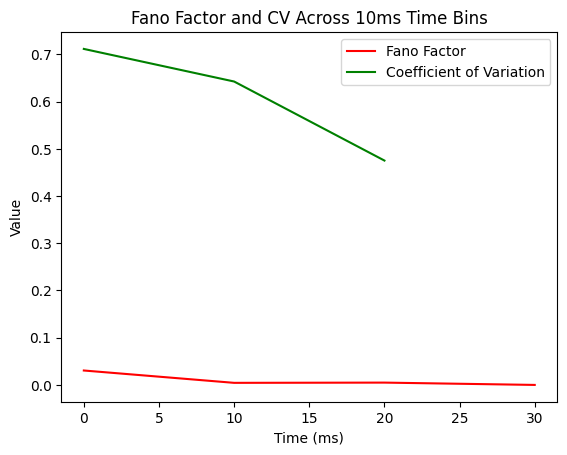

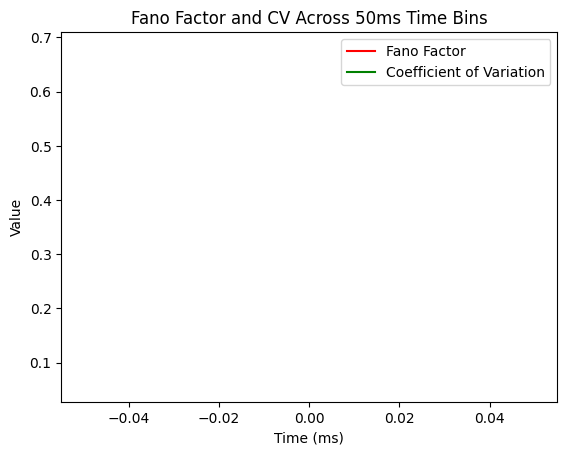

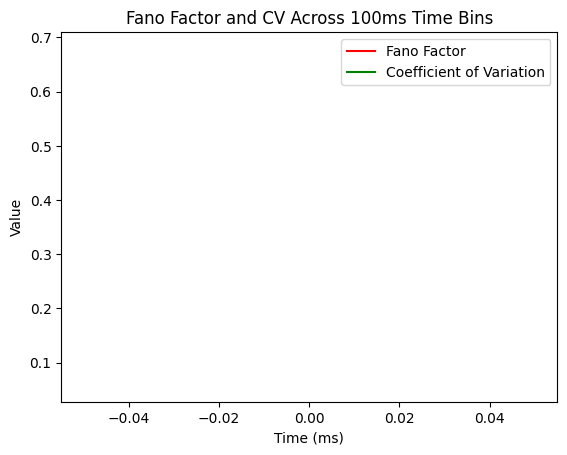

In [ ]:
#assuming generate_spike_train is defined elsewhere
spike_times, spike_train, isi_durations = generate_spike_train(fire_rate=35, dur_refract=0.005, total_time=0.5)

#define bin widths and split spike train
bin_sizes = [10, 50, 100]  # ms
sample_rate = 2  # 2 ms per sample

#create time bins
bins = {size: [spike_times[i:i + size // sample_rate] for i in range(0, len(spike_times), size // sample_rate)]
        for size in bin_sizes}

#initialize results dictionaries for Fano factor and CV
fano_results = {size: [] for size in bin_sizes}
cv_results = {size: [] for size in bin_sizes}

for size in bin_sizes:
    for chunk in bins[size]:
        #calculate Fano factor
        if len(chunk) > 0:  #avoid empty chunks
            fano = np.var(chunk) / np.mean(chunk) if np.mean(chunk) > 0 else np.nan
            fano_results[size].append(fano)
        
        #calculate coefficient of variation (CV)
        isi_durations_chunk = np.diff(chunk)
        if len(isi_durations_chunk) > 0 and np.mean(isi_durations_chunk) > 0:
            cv = np.std(isi_durations_chunk) / np.mean(isi_durations_chunk)
            cv_results[size].append(cv)
        else:
            cv_results[size].append(np.nan)

#print results
print("Fano Results:", fano_results)
print("CV Results:", cv_results)

#plotting results for each bin size
for size in bin_sizes:
    #create time bins in milliseconds
    time_bins = [i * size for i in range(len(fano_results[size]))]

    plt.plot(time_bins, fano_results[size], color='r', label="Fano Factor")
    plt.plot(time_bins, cv_results[size], color='g', label="Coefficient of Variation")
    plt.xlabel("Time (ms)")
    plt.ylabel("Value")
    plt.title(f"Fano Factor and CV Across {size}ms Time Bins")
    plt.legend()
    plt.show()
